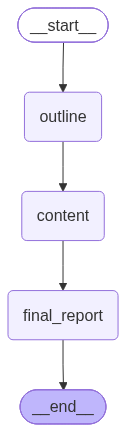


FINAL REPORT
Topic: Agentic AI
# **Report on Agentic AI: A Comprehensive Overview**

## **1. Introduction to Agentic AI**

Artificial Intelligence (AI) has evolved significantly over the past few decades, transitioning from static systems capable of simple tasks to dynamic, decision-making entities. Among the most advanced forms of AI is **Agentic AI**, a paradigm that enables machines to act autonomously, make decisions, and interact with the real world in a goal-oriented manner. Unlike traditional AI systems that rely on predefined scripts or rigid rules, agentic AI operates as an **agent**—an autonomous entity that can perceive its environment, reason, and execute actions to achieve specific objectives.

The concept of agentic AI draws inspiration from biological agents, such as animals or humans, which can sense their surroundings, process information, and take actions based on learned knowledge and adaptive strategies. In AI, this translates to systems that can perform tasks dyna

In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langchain_mistralai import ChatMistralAI

class State(TypedDict):
    topic: str
    outline: str
    content: str
    final_report: str

llm=ChatMistralAI(model='ministral-3b-latest')

def create_outline(state: State):
    topic = state["topic"]
    outline = f"""
1. Introduction to {topic}
2. Key concepts of {topic}
3. Applications of {topic}
4. Advantages and limitations
5. Conclusion
"""
    return {"outline": outline}

def write_content(state: State):
    topic = state["topic"]
    outline = state["outline"]
    prompt = f"""
You are a professional report writer.
Write a detailed report on the topic: {topic}
Use the following outline:
{outline}
Instructions:
- Write content for every heading in the outline.
- Keep each section clear and informative.
- Write proper paragraphs, not just bullet points.
- Explain important concepts in simple language.
- Include examples where appropriate.
- Make sure all five sections are covered.
"""
    response = llm.invoke(prompt)
    return {"content": response.content}

def create_final_report(state: State):
    topic = state["topic"]
    content = state["content"]
    final_report = f"""
========================================
FINAL REPORT
========================================
Topic: {topic}
{content}
========================================
"""
    return {"final_report": final_report}

graph_builder = StateGraph(State)
graph_builder.add_node("outline", create_outline)
graph_builder.add_node("content", write_content)
graph_builder.add_node("final_report", create_final_report)

# Sequential connections
graph_builder.add_edge(START, "outline")
graph_builder.add_edge("outline", "content")
graph_builder.add_edge("content", "final_report")
graph_builder.add_edge("final_report", END)

graph = graph_builder.compile()

result = graph.invoke({
    "topic": "Agentic AI",
    "outline": "",
    "content": "",
    "final_report": ""
})

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

print(result["final_report"])
